<h1 style = "text-align:center">Statistics for Decision Making</h1>

## Contents
1. [Importing Pertinent Python Libraries and Modules](#1.-Importing-Pertinent-Python-Libraries-and-Modules)
2. [Reading the File into a DataFrame](#2.-Reading-the-File-into-a-DataFrame)
3. [Understanding the Data](#3.-Understanding-the-Data)
4. [Preprocessing the Data](#4.-Preprocessing-the-Data)
5. [Problems and Solutions](#5.-Problems-and-Solutions)
    - [Problem 1](#Problem-1)
    - [Problem 2](#Problem-2)
    - [Problem 3](#Problem-3)
    - [Problem 4](#Problem-4)
    - [Problem 5](#Problem-5)
    - [Problem 6](#Problem-6)
    - [Problem 7](#Problem-7)
    - [Problem 8](#Problem-8)
    - [Problem 9](#Problem-9)
    - [Problem 10](#Problem-10)


<h3>1. Importing Pertinent Python Libraries and Modules</h3><a class = 'anchor' id = "intro" ></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

<h3>2. Reading the File into a DataFrame</h3><a class = 'anchor' id = "read"></a>

In [2]:
names = ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude',
       'Longitude', 'Regionname', 'PropertyCount']

In [3]:
df = pd.read_csv(r"property.csv",names = names,skiprows = 1)
df.sample(5)
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,PropertyCount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


<a class = 'anchor' id = "understand"></a>
<h3>3. Understanding the Data</h3>

In [4]:
df.shape

(13580, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Latitude       13580 non-null  float64
 18  Longit

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997e+00,0.955748,1.00000,2.000000,3.000000,3.000000e+00,1.000000e+01
Price,13580.0,1.075684e+06,639310.724296,85000.00000,650000.000000,903000.000000,1.330000e+06,9.000000e+06
Distance,13580.0,1.013778e+01,5.868725,0.00000,6.100000,9.200000,1.300000e+01,4.810000e+01
Postcode,13580.0,3.105302e+03,90.676964,3000.00000,3044.000000,3084.000000,3.148000e+03,3.977000e+03
Bedroom2,13580.0,2.914728e+00,0.965921,0.00000,2.000000,3.000000,3.000000e+00,2.000000e+01
Bathroom,13580.0,1.534242e+00,0.691712,0.00000,1.000000,1.000000,2.000000e+00,8.000000e+00
Car,13518.0,1.610075e+00,0.962634,0.00000,1.000000,2.000000,2.000000e+00,1.000000e+01
Landsize,13580.0,5.584161e+02,3990.669241,0.00000,177.000000,440.000000,6.510000e+02,4.330140e+05
BuildingArea,7130.0,1.519676e+02,541.014538,0.00000,93.000000,126.000000,1.740000e+02,4.451500e+04
YearBuilt,8205.0,1.964684e+03,37.273762,1196.00000,1940.000000,1970.000000,1.999000e+03,2.018000e+03


In [7]:
df.describe(exclude = [np.number]).T

,count,unique,top,freq
Suburb,13580,314,Reservoir,359
Address,13580,13378,36 Aberfeldie St,3
Type,13580,3,h,9449
Method,13580,5,S,9022
SellerG,13580,268,Nelson,1565
Date,13580,58,27/05/2017,473
CouncilArea,12211,33,Moreland,1163
Regionname,13580,8,Southern Metropolitan,4695


<a class = 'anchor' id = "preprocess"></a>
<h3>4. Preprocessing the Data</h3>

In [8]:
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Latitude            0
Longitude           0
Regionname          0
PropertyCount       0
dtype: int64

In [9]:
df["Car"].fillna(0, inplace = True)
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                 0
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Latitude            0
Longitude           0
Regionname          0
PropertyCount       0
dtype: int64

In [10]:
mapper = {
            "Suburb": "category",
            "Address": "string",
            "Type": "category",
            "Method": "category",
            "SellerG": "string",
            "Date": "datetime64[ns]",
            "CouncilArea": "string",
            "Regionname": "category",
            "Rooms": "int32",
            "Price": "float64",
            "Distance":"float32",
            "Postcode":"string",
            "Bedroom2":"int32",
            "Bathroom":"int32",
            "Car":"int32",
            "Landsize":"float32",
            "BuildingArea":"float32",
            "YearBuilt":"datetime64[ns]",
            "Latitude":"float64",
            "Longitude":"float64",
            "PropertyCount": "int64"
        }
df = df.astype(mapper)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13580 non-null  category      
 1   Address        13580 non-null  string        
 2   Rooms          13580 non-null  int32         
 3   Type           13580 non-null  category      
 4   Price          13580 non-null  float64       
 5   Method         13580 non-null  category      
 6   SellerG        13580 non-null  string        
 7   Date           13580 non-null  datetime64[ns]
 8   Distance       13580 non-null  float32       
 9   Postcode       13580 non-null  string        
 10  Bedroom2       13580 non-null  int32         
 11  Bathroom       13580 non-null  int32         
 12  Car            13580 non-null  int32         
 13  Landsize       13580 non-null  float32       
 14  BuildingArea   7130 non-null   float32       
 15  YearBuilt      8205

<h3>5. Problems and Solutions</h3>

<h4>Problem 1</h4> 

For the suburb of Altona, it is postulated that a typical property sells for $800,000.
- Use the data at hand to test this assumption.
- Is the typical property price really \$800,000 or has it increased?
- Use a significance level of 5%.

*Before choosing a test, we should check for Normality.*

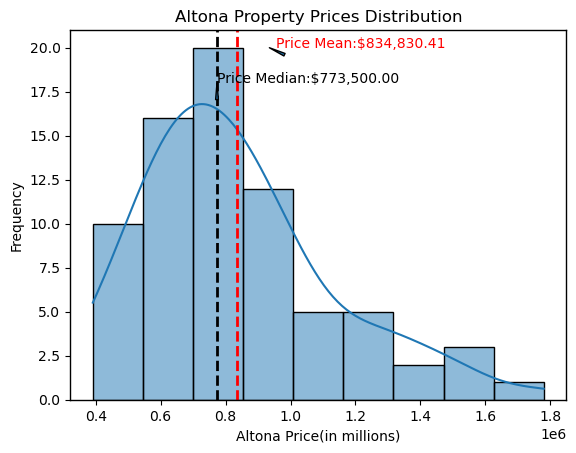

In [12]:
#Step 1: Test for Normality
#sns.set_theme()
Altona_prices = df[df["Suburb"] == "Altona"]["Price"]
plt.figure()
sns.histplot(x = Altona_prices, kde = True)
plt.xlabel("Altona Price(in millions)")
plt.ylabel("Frequency")
mean_val = Altona_prices.mean()
median_val = Altona_prices.median()
plt.axvline(mean_val,color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
plt.annotate(f"Price Mean:${mean_val:,.2f} ",xy =  (mean_val+100000,20),xytext = (mean_val+120000,20),color = "red",arrowprops = {"width" :1.0,"headwidth":2.0})
plt.axvline(median_val,color="black", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")
plt.annotate(f"Price Median:${median_val:,.2f} ", xy = (median_val,18),xytext = (median_val+3,18),color = "black",arrowprops = {"width" :1.0,"headwidth":2.0})
plt.title("Altona Property Prices Distribution")

ax = plt.gca()
ax.spines[:].set_visible(True)
ax.spines[:].set_linewidth(1.0)

plt.show()

*Based on the above graph, the data doesn't seem to be normally distributed, hence we run the Shapiro Wilk test.*

In [13]:
#Ascertain Normality using Shapiro Wilk Test
hyp = {'ho': "Altona Property Prices follows normal distribution",
       'h1': "Altona Property Prices doesn't follow normal distribution"}

alpha = 0.05

stat, p_val = ss.shapiro(Altona_prices)
print(f"Statistic: {stat}")
print(f"p-value: {p_val}")
if p_val<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['h1']} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['ho']} ")


Statistic: 0.9354839853451697
p-value: 0.0009449971757186169
Rejecting Null Hypothesis at 5.00% significance level which implies Altona Property Prices doesn't follow normal distribution 


*As the data doesn't follow a normal distribution, we should test the hypothesis using One-Sample Wilcoxon Signed Rank Test.*

In [14]:
#Hypothesis Definition
hyp = { "h0": "Altona Median Property Price is $800,000",
        "ha":"Altona Median Property Price is greater than $800,000" }

hyp_median = 800000
median_val = Altona_prices.median()
#Significance Level: alpha
alhpa = 0.05

#One- Sample Wilcoxin's test
result = ss.wilcoxon(Altona_prices - hyp_median, alternative = 'greater')

print(f"Statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")

if result.pvalue<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['ha'].lower()} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['h0'].lower()} ")

Statistic: 1381.0
P-value: 0.4334171838143706
Fail to reject the null hypothesis at 5.00% significance level which implies altona median property price is $800,000 


In [15]:
median_val

773500.0

<h4>Problem 2</h4>

For the year 2016, is there any difference in the prices of properties sold in the summer months vs winter months?
- Consider months from October till March as winter months and rest as summer months.
- Use a significance level of 5%.

In [16]:
bins = [1,4,10,12]
labels = ["winter", "summer","winter"]
df["Date"].dt.month
df["date_weather"] = pd.cut(df["Date"].dt.month, bins = bins, labels = labels, ordered = False, include_lowest = True)
df["date_weather"].unique()

['winter', 'summer']
Categories (2, object): ['summer', 'winter']

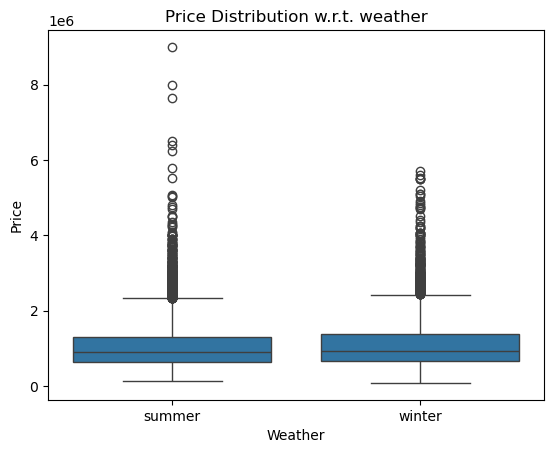

In [17]:
plt.figure()
sns.boxplot(data = df, x = "date_weather", y = "Price")
plt.xlabel("Weather")
plt.ylabel("Price")
plt.title("Price Distribution w.r.t. weather")
plt.show()

Since we know from the previous problem that the Price column is not normal, therefore, we will jump right to the Mann Whitney U-Rank test 
for Price for summer and winter months.

In [18]:
#Hypothesis Definition
hyp = { "h0":"Median Property Prices for summer and winter months are same",
        "ha":"Median Property Price for summer and winter months are not same" }

summer = df[df["date_weather"]=="summer"]["Price"]
winter = df[df["date_weather"]=="winter"]["Price"]
#Significance Level: alpha
alpha = 0.05

#Run the non-parametric Mann-Whitney U test (two-sided)
stats, p_value = ss.mannwhitneyu(summer,winter, alternative = "two-sided")
print(f"Statistic: {stats}")
print(f"p-value: {p_value}")

if p_value<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['ha'].lower()} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['h0'].lower()} ")

Statistic: 20098155.5
p-value: 9.02439802077273e-05
Rejecting Null Hypothesis at 5.00% significance level which implies median property price for summer and winter months are not same 


<h4>Problem 3</h4> 

For the suburb of Abbotsford, what is the probability that out of 10 properties sold, 3 will not have a car parking space?
- Use the column car in the dataset.
- Round off your answer to 3 decimal places.

In [19]:
abbotsford = df[df["Suburb"] == "Abbotsford"]

total = abbotsford["Car"].shape[0]
no_car = (abbotsford["Car"] == 0).sum()
prob_no_car = no_car/total
print(total, no_car,prob_no_car)
n = 10
k = 3

prob =  ss.binom.pmf(k,n,prob_no_car)

print(f"Probability that out of 10 properties sold, 3 will not have a car parking space is {prob:.3f}")

56 15 0.26785714285714285
Probability that out of 10 properties sold, 3 will not have a car parking space is 0.260


<h4>Problem 4</h4>
In the suburb of Abbotsford, what are the chances of finding a property with 3 rooms? Round your answer to 3 decimal places.b

In [20]:
prob_3_rooms = abbotsford[abbotsford["Rooms"] == 3].shape[0]/abbotsford.shape[0]

print(f"The probability of finding a property with 3 rooms in Abbotsford is {prob_3_rooms:.3f}")

The probability of finding a property with 3 rooms in Abbotsford is 0.357


<h4>Problem 5</h4>
In the suburb of Abbotsford, what are the chances of finding a property with 2 bathrooms? Round your answer to 3 decimal places.

In [21]:
prob_2_bath = abbotsford[abbotsford["Bathroom"] == 2].shape[0]/abbotsford.shape[0]

print(f"The probability of finding a property with 2 bathrooms in Abbotsford is {prob_2_bath:.3f}")

The probability of finding a property with 2 bathrooms in Abbotsford is 0.339


<h4>Problem 6</h4>

One-Sample Hypothesis Test (Industry Pricing) A real estate firm claims that the average property price in Richmond is $1,000,000. Using the dataset, test whether the actual average price is significantly different from this claim at a 5% significance level. Clearly state:
- Null and alternative hypotheses
- Test statistic
- p-value
- Final business conclusion

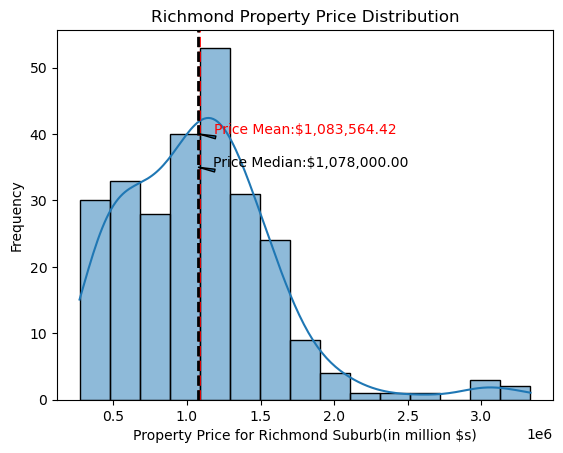

In [22]:
Price_Richmond = df[df["Suburb"]  == "Richmond"]["Price"]

plt.figure()
sns.histplot(x = Price_Richmond,kde = True)
plt.xlabel("Property Price for Richmond Suburb(in million $s)")
plt.ylabel("Frequency")
mean_val = Price_Richmond.mean()
median_val = Price_Richmond.median()
plt.axvline(mean_val,color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
plt.annotate(f"Price Mean:${mean_val:,.2f} ", xy = (mean_val,40),xytext = (mean_val+100000,40),color = "red",arrowprops = {"width" :1.0,"headwidth":2.0})
plt.axvline(median_val,color="black", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")
plt.annotate(f"Price Median:${median_val:,.2f} ",xy =  (median_val,35),xytext = (median_val+100000,35),color = "black",arrowprops = {"width" :1.0,"headwidth":2.0})
plt.title("Richmond Property Price Distribution")
plt.show()



In [23]:
#Ascertain Normality using Shapiro Wilk Test
hyp = {'ho': "Richmmond Property Price follows normal distribution",
       'h1': "Richmond Property Price doesn't follow normal distribution"}

alpha = 0.05

stat, p_val = ss.shapiro(Price_Richmond)
print(f"Statistic: {stat}")
print(f"p-value: {p_val}")
if p_val<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['h1']} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['ho']} ")

Statistic: 0.9198681195105054
p-value: 1.3121629794557238e-10
Rejecting Null Hypothesis at 5.00% significance level which implies Richmond Property Price doesn't follow normal distribution 


In [24]:
#Hypothesis Definition
hyp = { "h0":"Richmond Median Property Price is $1,000,000",
        "ha":"Richmond Median Property Price is not $1,000,000" }

hyp_median = 1000000
median_val = Price_Richmond.median()
#Significance Level: alpha
alpha = 0.05

#One- Sample Wilcoxin's test
result = ss.wilcoxon(Price_Richmond - hyp_median, alternative='two-sided')

print(f"Statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")

if result.pvalue<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['ha'].lower()} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['h0'].lower()} ")

Statistic: 14882.5
P-value: 0.105661551012246
Fail to reject the null hypothesis at 5.00% significance level which implies richmond median property price is $1,000,000 


With a p-value of 0.1057, which is greater than our significance level ($\alpha = 0.05$), we fail to reject the null hypothesis. There is no statistically significant evidence to contradict the real estate firm's claim. From a business perspective, stakeholders can confidently accept $1,000,000 as an accurate benchmark for typical property values in Richmond when budgeting or evaluating investment portfolios.

<h4>Problem 7</h4>

Independent Two-Sample T-Test (Feature Impact)
Do properties with car parking sell at a higher average price than properties without car parking, across the entire dataset? Use a 5% significance level and justify:
- Choice of test
- Interpretation of p-value
- Business implications for developers

In [25]:
#Hypothesis Definition
hyp = { "h0":"Prices of properties with car parking are same as prices of properties without car parking ",
        "ha":"Prices of properties with car parking are greater than prices of properties without car parking" }
#Significance Level: alpha
alpha = 0.05
#Two Sample T-Test
Sample_1 = df[df["Car"] >= 1]["Price"]
Sample_2 = df[df["Car"] == 0]["Price"]

tstats, pvalue = ss.ttest_ind(Sample_1, Sample_2, alternative = "greater")

print(f"Statistic: {tstats}")
print(f"P-value: {pvalue}")

if pvalue<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['ha'].lower()} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['h0'].lower()} ")


Statistic: -0.7659649815858638
P-value: 0.7781447730313326
Fail to reject the null hypothesis at 5.00% significance level which implies prices of properties with car parking are same as prices of properties without car parking  


From a business perspective, the statistical analysis reveals that properties with car parking do not command a higher average sale price across the entire dataset compared to those without. For developers, this suggests that dedicating expensive square footage or structural costs to building parking spaces may not yield a premium premium return on investment in this market configuration. They might optimize profitability by reallocating that space toward living areas or additional rooms instead.

<h4>Problem 8</h4>

Two-Way ANOVA (Location & Property Type)
Investigate whether property prices are influenced by:
- Suburb
- Type of property
- Interaction between suburb and property type
Use Two-Way ANOVA and explain which factors significantly affect price.

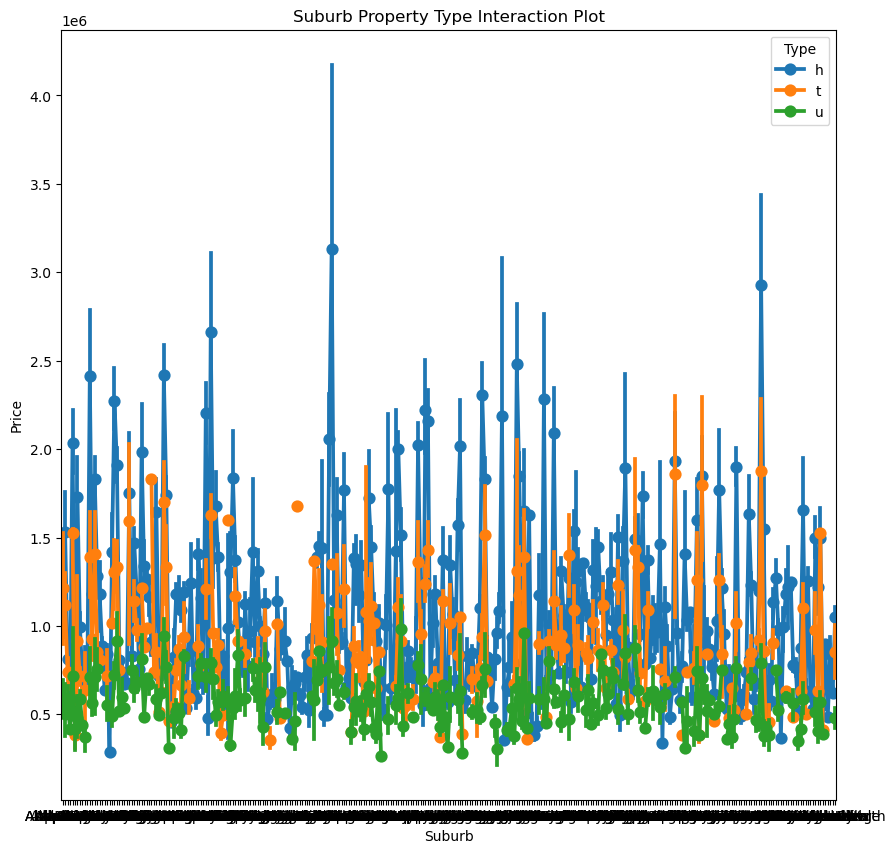

'Parallel lines: No interation\n   Crossed Lines: Interation exists'

In [26]:
plt.figure(figsize = (10,10))
sns.pointplot(data = df, x = 'Suburb', y = 'Price', hue = 'Type')
plt.title('Suburb Property Type Interaction Plot')
plt.show()
"""Parallel lines: No interation
   Crossed Lines: Interation exists"""

In [27]:
model = ols('Price ~ Suburb * Type', data=df).fit()
anova_table = sm.stats.anova_lm(model,typ =2)
print(anova_table)

                   sum_sq       df          F         PR(>F)
Suburb       3.847402e+15    313.0  76.593401   0.000000e+00
Type                  NaN      2.0        NaN            NaN
Suburb:Type  6.470034e+14    626.0   6.440216  2.505093e-263
Residual     2.068639e+15  12890.0        NaN            NaN


Interpretation:
1. The Suburb effect is massive with an f-statistic of 76.593 which means locations is a powerful predictor of property prices.
2. While individual property type main effects are structurally constrained in this global model, the interaction term proves that property type's impact on price is heavily tied to location.

<h4>Problem 9</h4>

p-Value Interpretation (Decision Making)
A hypothesis test comparing prices across two suburbs results in a p-value of 0.032.
Answer:
- What does this p-value indicate?
- Should the null hypothesis be rejected at α = 0.05?
- How should a business stakeholder interpret this result?

**Solution**
- The p-value indicates that if the average prices of both suburbs were actually identical (Null Hypothesis is true), there is only a 3.2% chance we would see a price difference this large due to random sampling variations.
- If the significance level,α =  0.05 or 5% is considered, then the p-value will be less than the significance level, this would be mean that we reject the null hypothesis.
- For the business case, stakeholders should conclude that there is a statistically significant difference in property prices between these two suburbs. They should not treat them as having the same baseline market value when pricing properties or planning investments.

<h4>Problem 10</h4>

Industry-Style Hypothesis Validation (Policy Decision)
A housing policy group believes that properties with more than 2 bathrooms command a premium price.
Design and execute a statistical test to validate this claim:
- Identify the correct test
- State hypotheses
- Report p-value
- Give a clear recommendation to policymakers

In [28]:
#Hypothesis Definition
hyp = { "h0":"Prices of properties with more than 2 bathrooms are same as prices of properties with up to 2 bathrooms",
        "ha":"Prices of properties with more than 2 bathrooms are greater than prices of properties with up to 2 bathrooms" }
#Significance Level: alpha
alpha = 0.05
#Two Sample T-Test
Sample_1 = df[df["Bathroom"] > 2]["Price"]
Sample_2 = df[df["Bathroom"] <=2]["Price"]

tstats, pvalue = ss.ttest_ind(Sample_1, Sample_2, alternative = "greater")

print(f"Statistic: {tstats:.4f}")
print(f"P-value: {pvalue:.4e}")

if pvalue<alpha:
    print(f"Rejecting Null Hypothesis at {(alpha):.2%} significance level which implies {hyp['ha'].lower()} ") 
else:
    print(f"Fail to reject the null hypothesis at {(alpha):.2%} significance level which implies {hyp['h0'].lower()} ")

Statistic: 46.0260
P-value: 0.0000e+00
Rejecting Null Hypothesis at 5.00% significance level which implies prices of properties with more than 2 bathrooms are greater than prices of properties with up to 2 bathrooms 


The data provides overwhelming statistical evidence that properties with more than 2 bathrooms command a significant price premium in the market. Policymakers and urban planners should take this value driver into account when drafting affordable housing regulations or density guidelines, as mandated higher bathroom counts will inherently elevate the market baseline price of newly built residential assets.